In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

In [3]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [4]:
# REMOVE ELECTRONS!!!!

In [5]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [6]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [7]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0.5e3            # V
line['frf'] = 1 / tw4d.t_rev0 # h=1

env['dp'] = 0
line.append(
    env.new('tdelay', xt.TimeDelay, shift_zeta=-eta * line_length * env.ref['dp']))

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [14]:
tw4d.momentum_compaction_factor

np.float64(0.2742125337468512)

In [8]:
# Going for natural chroma
env['ksf'] = 0
env['ksd'] = 0

In [9]:
env['dp'] = -2.5e-3
tw_carbon = line.twiss6d()
tw_helium = line.twiss6d(mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

In [10]:
alpha_c = tw_carbon.momentum_compaction_factor
eta_c = tw_carbon.slip_factor
chi_he = tw_helium.particle_on_co.chi[0]
delta_diff_expected = alpha_c / eta_c * (chi_he - 1)

In [11]:
chi_he

np.float64(0.9993495023718296)

In [13]:
alpha_c

np.float64(0.26931729895324696)

In [12]:
float(delta_diff_expected), float(tw_helium.delta[0] - tw_carbon.delta[0])

(0.0004290248004171206, 0.00043662642462583)

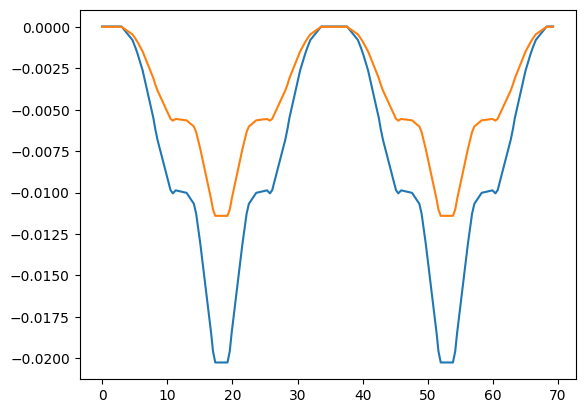

In [13]:
plt.plot(tw_carbon.s, tw_carbon.x)
plt.plot(tw_carbon.s, tw_helium.x)

In [14]:
delta_test = np.linspace(-1e-3, 1e-3, 20)
p_carbon = line.build_particles(delta=tw_carbon.delta[0] + delta_test)
p_helium = line.build_particles(delta=tw_helium.delta[0] + delta_test, mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

In [15]:
num_turns=5000
line.track(p_carbon, num_turns=num_turns, turn_by_turn_monitor=True, with_progress=10)
mon_carbon = line.record_last_track.copy()

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

In [16]:
line.track(p_helium, num_turns=num_turns, turn_by_turn_monitor=True, with_progress=10)
mon_helium = line.record_last_track.copy()

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

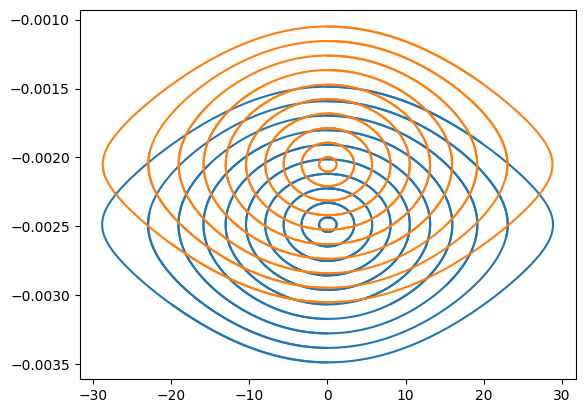

In [17]:
plt.plot(mon_carbon.zeta.T, mon_carbon.delta.T, color='C0')
plt.plot(mon_helium.zeta.T, mon_helium.delta.T, color='C1');